In [1]:
#! pip uninstall torch torchvision torchaudio -y
#! pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?
print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?


True
12.8
NVIDIA GeForce RTX 4070 SUPER


In [3]:
#! pip install opencv-python pandas

In [4]:
import os
import cv2
import pandas as pd

ruta_base = "/home/jeff/Trabajo/Cedulas/imagenes_cedula_peq"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())

                                                Path            Label  \
0  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
1  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
2  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
3  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   
4  /home/jeff/Trabajo/Cedulas/imagenes_cedula_peq...  Cedula_Amarilla   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


/tmp/ipykernel_48063/3432273608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')


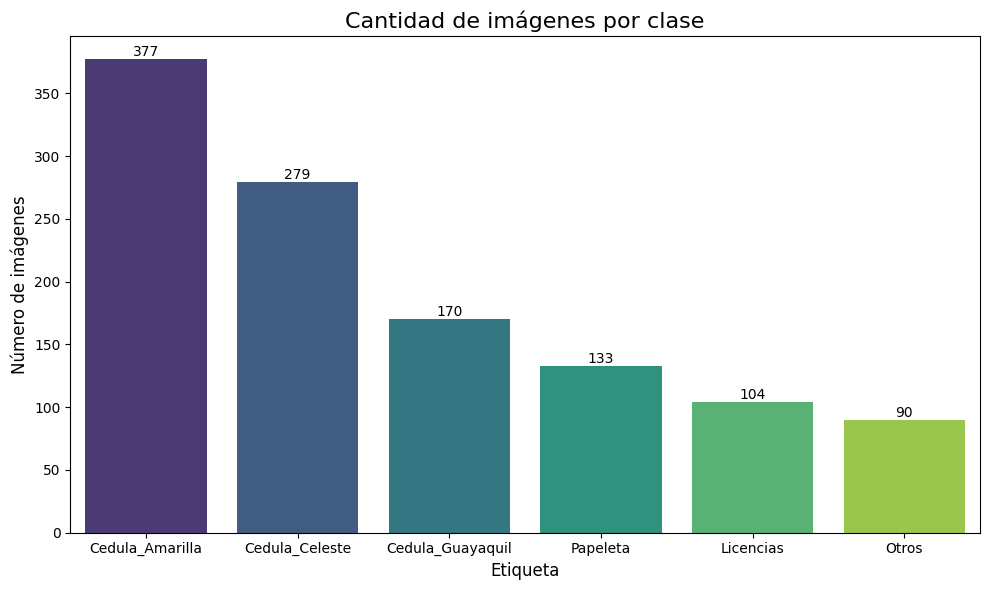

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo de imágenes por clase
conteo = df['Label'].value_counts().reset_index()
conteo.columns = ['Label', 'Cantidad']

# Crear figura
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')

# Mostrar los valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',               # texto
                (p.get_x() + p.get_width() / 2., height),  # posición
                ha='center', va='bottom', fontsize=10)

# Personalización del gráfico
plt.title('Cantidad de imágenes por clase', fontsize=16)
plt.xlabel('Etiqueta', fontsize=12)
plt.ylabel('Número de imágenes', fontsize=12)
plt.tight_layout()
plt.show()


In [6]:
import torch
from torchvision import models, transforms
import torch.nn as nn
import cv2

# 1. Modelo MobileNetV2 con avgpool
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")
feature_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # ↓ reduce a (batch_size, 1280, 1, 1)
)
feature_extractor.eval()

# 2. Preprocesamiento estándar (IMAGENET compatible)
preprocess = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # mejor usar valores de imagenet
                             std=[0.229, 0.224, 0.225]),
    ]
)

# 3. Extraer vectores
features_list = []
labels_list = []

def extract_feature_vector(image_path: str) -> torch.Tensor:
    """
    Extrae un vector de características de tamaño (1280,) de una imagen usando MobileNetV2.

    Args:
        image_path (str): Ruta al archivo de imagen.

    Returns:
        np.ndarray: Vector de características de tamaño (1280,) o None si hay error.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"[WARNING] No se pudo cargar la imagen: {image_path}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = preprocess(img_rgb).unsqueeze(0)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        vector = features.view(-1).numpy()  # → shape: (1280,)
    
    return vector

for i, row in df.iterrows():
    image_pros=extract_feature_vector(row["Path"])
    features_list.append(image_pros)
    labels_list.append(row["Label_decode"])



In [7]:
print(features_list[0].shape)

(1280,)


In [8]:
from sklearn.manifold import TSNE
import numpy as np
# Convertir a array
X = np.array(features_list)
y = np.array(labels_list)

# Ejecutar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)


/home/jeff/anaconda3/envs/trabajo/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


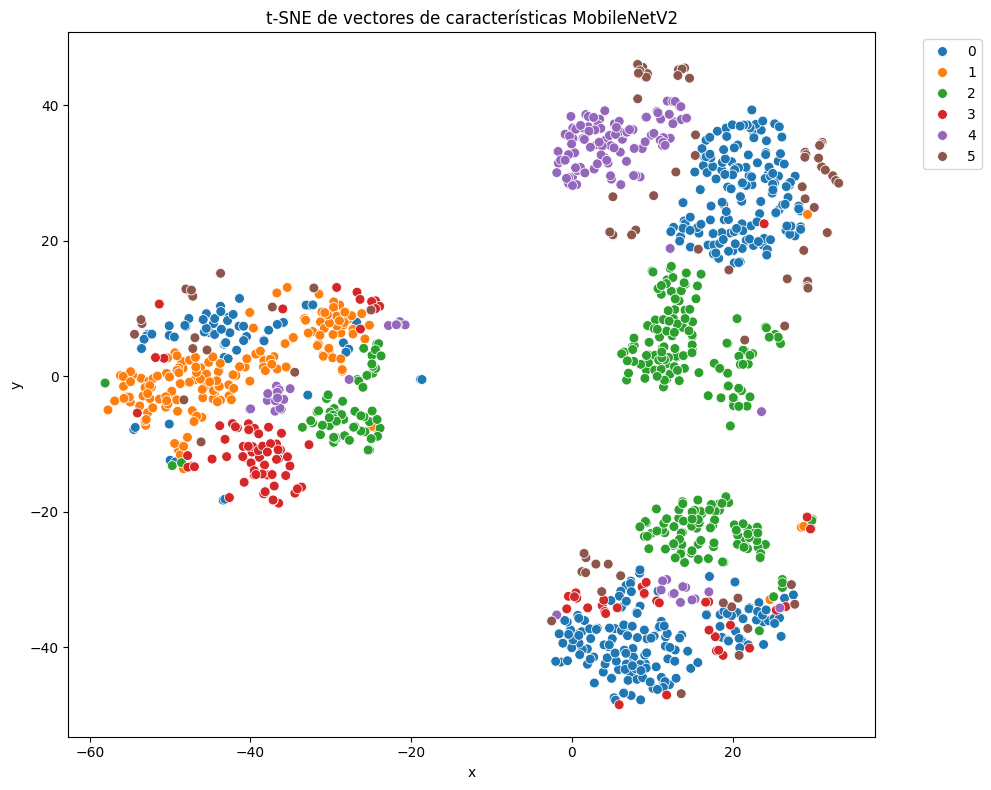

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame para graficar
tsne_df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "Label": y
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="Label", palette="tab10", s=50)
plt.title("t-SNE de vectores de características MobileNetV2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [10]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import lightning as L
from sklearn.model_selection import train_test_split, StratifiedKFold


class MyDataModule(L.LightningDataModule):
    def __init__(self, X, y, batch_size=64, clases=1, kfold=2):
        super().__init__()
        self.batch_size = batch_size
        self.num_classes = clases
        self.kfold = kfold
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.folder = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

    def prepare_data(self):
        # Split data once
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=0.3,
            random_state=42,
            stratify=self.y,
            shuffle=True,
        )
        self.kfolder = list(self.folder.split(X=self.X_train, y=self.y_train))
        self.input_shape = self.X_train.shape[1]  # assuming shape = [N, features]

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            X_train_fold = self.X_train[train_idx]
            y_train_fold = self.y_train[train_idx]
            X_val_fold = self.X_train[val_idx]
            y_val_fold = self.y_train[val_idx]

            self.train_dataset = TensorDataset(X_train_fold, y_train_fold)
            self.val_dataset = TensorDataset(X_val_fold, y_val_fold)

        if stage == "test" or stage is None:
            self.test_dataset = TensorDataset(self.X_test, self.y_test)

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self, data=None):
        if data == None:
            return DataLoader(
                self.predict_dataset,
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            return DataLoader(
                data,
                batch_size=self.batch_size,
                shuffle=False,
            )

In [11]:
dataset=MyDataModule(X,y,clases=6,kfold=5)
dataset.prepare_data()
dataset.setup()

In [46]:
from torchmetrics import F1Score

class Mymodel(L.LightningModule):
    def __init__(self, input_shape, num_classes, hidden_units, lambda_reg=0.0001, regularization=None):
        super().__init__()
        self.save_hyperparameters()
        self.hidden_units = hidden_units
        self.lambda_reg = lambda_reg
        self.regularization = regularization

        layers = [nn.Flatten()]
        for units in hidden_units:
            layers.append(nn.Linear(input_shape, units))
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.LeakyReLU(negative_slope=0.01))
            input_shape = units
        
        layers.append(nn.Linear(input_shape, num_classes))
        layers.append(nn.LogSoftmax(dim=1))

        self.classifier = nn.Sequential(*layers)
        
        self.loss = nn.NLLLoss()
        self.f1 = F1Score(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.classifier(x)

    def configure_optimizers(self):
        if self.regularization == "L2":
            return torch.optim.Adam(self.parameters(), lr=0.0001, weight_decay=self.lambda_reg)
        else:
            return torch.optim.Adam(self.parameters(), lr=0.0001)

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_f1', f1_score, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('val_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('val_f1', f1_score, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('test_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('test_f1', f1_score, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        log_probs = self.forward(x)
        probs = torch.exp(log_probs)
        return probs

    def on_validation_epoch_start(self):
        self.f1.reset()


In [47]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)
print(torch.version.__version__)

True
1
12.8
2.7.1+cu128


In [68]:
lambda_ = 0.001
epochs = 1000  # Number of epochs for training
hidden_units = [254, 254, 254]
regul = "L1"
# hidden_units = [[32, 32, 32], [64, 64, 64], [128, 128, 128], [16, 32, 64, 128]]
# regul = ["L1", "L2"]

In [69]:

results = [[], []]
for i in range(dataset.kfold):
    early_stop_callback = None
    checkpoint_callback = None
    model = None
    trainer = None
    model = Mymodel(
        input_shape=dataset.input_shape,
        num_classes=dataset.num_classes,
        hidden_units=hidden_units,
        lambda_reg=lambda_,
        regularization=regul,
    )
    early_stop_callback = L.pytorch.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
    )

    checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
        save_top_k=2,
        save_last=True,
        monitor="val_loss",
        mode="min",
    )

    callbacks = [early_stop_callback, checkpoint_callback]

    trainer = L.Trainer(
        max_epochs=epochs,
        callbacks=callbacks,
        accelerator="gpu" if device.type == "cuda" else "cpu",
        devices=1,
    )

    dataset.setup(stage="fit", n_fold=i)

    trainer.fit(
        model,
        train_dataloaders=dataset.train_dataloader(),
        val_dataloaders=dataset.val_dataloader(),
    )

    result_val = trainer.validate(
        model,
        dataloaders=dataset.val_dataloader(),
        ckpt_path="best",
    )
    result_test = trainer.test(
        model,
        dataloaders=dataset.test_dataloader(),
        ckpt_path="best",
    )
    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type              | Params | Mode 
---------------------------------------------------------
0 | classifier | Sequential        | 457 K  | train
1 | loss       | NLLLoss           | 0      | train
2 | f1         | MulticlassF1Score | 0      | train
---------------------------------------------------------
457 K     Trainable params
0         Non-trainable params
457 K     Total params
1.832     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 40: 100%|██████████| 11/11 [00:00<00:00, 58.00it/s, v_num=19, val_loss_step=0.173, val_f1_step=1.000, val_loss_epoch=0.205, val_f1_epoch=0.957]


Restoring states from the checkpoint path at /home/jeff/Trabajo/Cedulas/lightning_logs/version_19/checkpoints/epoch=35-step=396.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/jeff/Trabajo/Cedulas/lightning_logs/version_19/checkpoints/epoch=35-step=396.ckpt


Validation DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 159.91it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_f1_epoch          0.9444444179534912
     val_loss_epoch         0.19753319025039673
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Restoring states from the checkpoint path at /home/jeff/Trabajo/Cedulas/lightning_logs/version_19/checkpoints/epoch=35-step=396.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/jeff/Trabajo/Cedulas/lightning_logs/version_19/checkpoints/epoch=35-step=396.ckpt


...

Validation DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 136.25it/s]

Restoring states from the checkpoint path at /home/jeff/Trabajo/Cedulas/lightning_logs/version_23/checkpoints/epoch=22-step=253.ckpt



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_f1_epoch          0.9378882050514221
     val_loss_epoch         0.2690957188606262
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/jeff/Trabajo/Cedulas/lightning_logs/version_23/checkpoints/epoch=22-step=253.ckpt


Testing DataLoader 0: 100%|██████████| 6/6 [00:00<00:00, 144.38it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_f1_epoch         0.9682080745697021
     test_loss_epoch        0.21083132922649384
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [70]:
model = Mymodel.load_from_checkpoint("/home/jeff/Trabajo/Cedulas/lightning_logs/version_6/checkpoints/last.ckpt")
model.eval()  # Cambia a modo de evaluación


Mymodel(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1280, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=32, out_features=32, bias=True)
    (8): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=32, out_features=6, bias=True)
    (11): LogSoftmax(dim=1)
  )
  (loss): NLLLoss()
  (f1): MulticlassF1Score()
)

In [71]:
trainer = L.Trainer()
predicciones = trainer.predict(model, dataloaders=dataset.predict_dataloader())  # dataset es tu DataModule


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 6/6 [00:00<00:00, 410.20it/s]


In [72]:
print(predicciones)

[tensor([[0.0933, 0.1024, 0.0163, 0.7258, 0.0132, 0.0491],
        [0.4188, 0.0670, 0.0601, 0.0551, 0.2828, 0.1162],
        [0.0399, 0.0284, 0.8544, 0.0522, 0.0131, 0.0120],
        [0.7873, 0.0488, 0.0375, 0.0225, 0.0530, 0.0508],
        [0.3769, 0.0631, 0.0493, 0.2889, 0.0731, 0.1487],
        [0.9199, 0.0170, 0.0130, 0.0191, 0.0150, 0.0159],
        [0.1178, 0.0459, 0.0097, 0.0097, 0.7843, 0.0325],
        [0.1248, 0.0871, 0.0286, 0.0248, 0.6528, 0.0819],
        [0.0558, 0.0941, 0.0276, 0.0682, 0.0411, 0.7133],
        [0.1619, 0.0436, 0.0151, 0.7102, 0.0123, 0.0568],
        [0.7826, 0.0309, 0.0346, 0.0447, 0.0606, 0.0465],
        [0.9039, 0.0168, 0.0164, 0.0194, 0.0236, 0.0200],
        [0.0887, 0.0474, 0.0070, 0.0066, 0.8181, 0.0323],
        [0.0617, 0.1492, 0.6905, 0.0501, 0.0206, 0.0278],
        [0.6828, 0.0496, 0.0488, 0.0575, 0.1112, 0.0501],
        [0.7694, 0.0516, 0.0307, 0.0476, 0.0493, 0.0514],
        [0.8195, 0.0306, 0.0390, 0.0344, 0.0342, 0.0422],
        [0.09

In [73]:
# 4. Procesar predicciones
predicciones= list(predicciones)
for batch in predicciones:
    clases_predichas = torch.argmax(batch, dim=1)
    print(clases_predichas)

tensor([3, 0, 2, 0, 0, 0, 4, 4, 5, 3, 0, 0, 4, 2, 0, 0, 0, 3, 2, 2, 2, 0, 1, 2,
        2, 4, 2, 3, 0, 1, 1, 2, 4, 5, 3, 2, 4, 2, 4, 0, 0, 4, 1, 2, 0, 3, 3, 0,
        3, 4, 0, 0, 0, 0, 0, 3, 0, 2, 4, 0, 0, 0, 1, 0])
tensor([0, 2, 0, 0, 0, 2, 5, 5, 1, 0, 0, 3, 1, 2, 0, 1, 1, 1, 1, 2, 5, 0, 1, 0,
        2, 0, 3, 0, 4, 4, 2, 0, 4, 1, 1, 4, 0, 1, 0, 0, 5, 2, 0, 1, 2, 2, 0, 4,
        1, 2, 5, 2, 3, 5, 2, 0, 3, 1, 1, 0, 3, 3, 4, 2])
tensor([1, 5, 2, 2, 3, 0, 0, 2, 0, 0, 0, 4, 2, 2, 0, 0, 0, 2, 3, 2, 3, 0, 1, 0,
        1, 5, 2, 0, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 2, 1, 2, 0, 5, 0, 4,
        0, 0, 1, 4, 0, 0, 0, 1, 0, 0, 5, 0, 2, 5, 4, 1])
tensor([1, 1, 4, 5, 0, 0, 3, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 4, 0, 5, 5, 0,
        5, 1, 4, 2, 3, 0, 1, 2, 0, 2, 0, 0, 4, 0, 0, 0, 0, 2, 1, 0, 2, 4, 0, 2,
        1, 2, 0, 1, 0, 0, 2, 2, 1, 0, 0, 3, 0, 2, 0, 2])
tensor([5, 0, 0, 2, 2, 0, 0, 0, 1, 1, 4, 0, 2, 1, 0, 1, 2, 2, 4, 2, 5, 0, 0, 1,
        4, 1, 0, 2, 4, 1, 2, 2, 2, 0, 2, 4, 2, 1, 4,